In [1]:
import os
import pickle

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from adjustText import adjust_text
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import r2_score, mean_absolute_error
from matplotlib import rcParams
import re

# === 0. Plot Settings (Matches your reference) ===
rcParams['pdf.fonttype'] = 42 
rcParams['ps.fonttype'] = 42   
rcParams['font.family'] = 'DejaVu Sans'

Loading Expression Data...
Computing Benefit Scores...
  > Genes used for scoring: 187
Generating Plot...


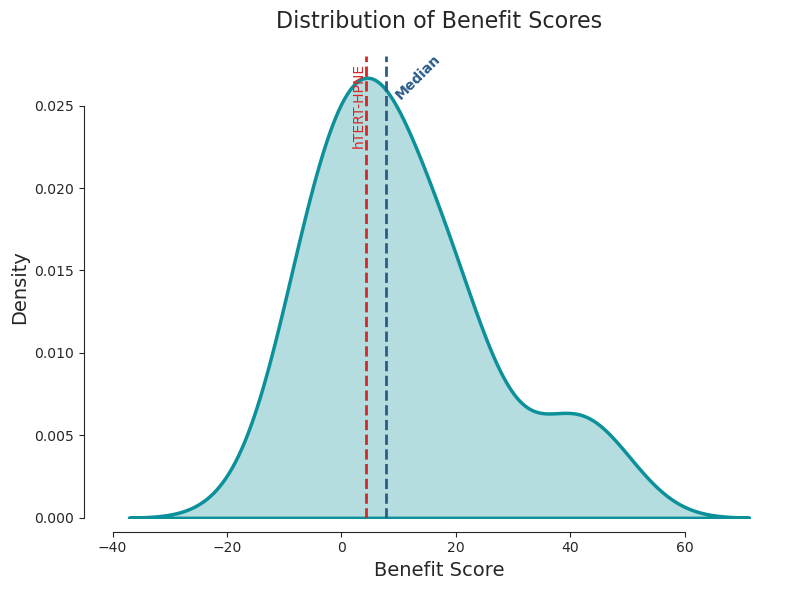

In [2]:


# ==========================================
# 1. Configuration & Data Loading
# ==========================================
FILE_PATH = '/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/Tahoe_analysis/Tahoe_voom_exp_final.csv'
WEIGHTS_PATH = '/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/git_repo/Data/EGFR_ERLOTINIB_geneImp_optuna.csv'


# Load Expression Data
print("Loading Expression Data...")
df = pd.read_csv(FILE_PATH)

# Set index and drop 'clean_id' if present
if 'Unnamed: 0' in df.columns:
    df.set_index('Unnamed: 0', inplace=True)

if 'clean_id' in df.columns:
    df.drop(columns=['clean_id'], inplace=True)
    
alias_map = {
    'ENSG00000253102': 'LRRC59-AS1',
    'ENSG00000228925': 'MCFD2-AS1',
    'ENSG00000241073': 'MFSD14A-AS1',
    'ENSG00000227741': 'PEA15-AS1',
    'KIAA1522': 'NHSL3'
}

# Rename the columns
df = df.rename(columns=alias_map)

# Ensure all data is numeric (genes only)
df = df.select_dtypes(include=[np.number])

# ==========================================
# 2. Metadata Parsing
# ==========================================
def parse_sample_info(sample_id):
    """
    Parses index strings to extract metadata.
    """
    # Case 1: DMSO
    dmso_match = re.search(r'DMSO_Plate_(\d+)_(CVCL_[A-Za-z0-9]+)', sample_id)
    if dmso_match:
        return {
            'sample_id': sample_id,
            'treatment': 'DMSO',
            'cell_line': dmso_match.group(2)
        }

    # Case 2: Erlotinib
    drug_match = re.search(r'Erlotinib_([0-9\.]+)_(CVCL_[A-Za-z0-9]+)', sample_id)
    if drug_match:
        return {
            'sample_id': sample_id,
            'treatment': 'Erlotinib',
            'cell_line': drug_match.group(2)
        }
    
    return {'sample_id': sample_id, 'treatment': 'Unknown', 'cell_line': 'Unknown'}

# Create Metadata DataFrame
meta_list = [parse_sample_info(idx) for idx in df.index]
metadata = pd.DataFrame(meta_list).set_index('sample_id')

# ==========================================
# 3. Compute Tahoe Benefit Score (DMSO only)
# ==========================================
print("Computing Benefit Scores...")

try:
    gene_weights = pd.read_csv(WEIGHTS_PATH, index_col=0)
    # Assume weights are in the first column or specific column
    weight_col = 'scaled_combined' if 'scaled_combined' in gene_weights.columns else gene_weights.columns[0]
    weights = gene_weights[weight_col]
    
    # Intersection of genes
    common_genes = df.columns.intersection(weights.index)
    print(f"  > Genes used for scoring: {len(common_genes)}")
    
    if len(common_genes) == 0:
        raise ValueError("No overlapping genes found between data and weight file.")

    # Filter data and weights
    weights_aligned = weights.loc[common_genes]
    
    # 1. Get all DMSO samples
    dmso_samples = metadata[metadata['treatment'] == 'DMSO'].index
    dmso_expression = df.loc[dmso_samples, common_genes]
    
    # 2. Calculate raw scores (Dot Product)
    raw_scores = dmso_expression.dot(weights_aligned)
    
    # 3. Add Cell Line info 
    score_df = pd.DataFrame(raw_scores, columns=['score'])
    score_df['cell_line'] = metadata.loc[dmso_samples, 'cell_line']
    
    # 4. Average score per cell line (across plates)
    avg_benefit_scores = score_df.groupby('cell_line')['score'].mean()

except FileNotFoundError:
    print("  > Weight file not found! Generating DUMMY scores for demo.")
    unique_cells = metadata['cell_line'].unique()
    avg_benefit_scores = pd.Series(np.random.normal(loc=5, scale=15, size=len(unique_cells)), index=unique_cells)

# ==========================================
# 4. Plotting Distribution (Figure E Style)
# ==========================================
print("Generating Plot...")

plt.figure(figsize=(8, 6))
sns.set_style("ticks") # Clean style with ticks, no grid

# 1. Draw Density Plot (KDE)
# Using a teal color similar to the screenshot
ax = sns.kdeplot(
    data=avg_benefit_scores, 
    fill=True, 
    color="#0c919a",  # Teal color
    alpha=0.3,        # Transparency of fill
    linewidth=2.5     # Thickness of the outline
)

# 2. Calculate Statistics
median_val = avg_benefit_scores.median()

# Optional: Find a specific cell line to highlight (like hTERT-HPNE in the image)
specific_cell = 'CVCL_C466' # Example ID for hTERT-HPNE if known, otherwise set None
specific_val = avg_benefit_scores.get(specific_cell, None)

# 3. Add Median Line
plt.axvline(x=median_val, color='#2b5c8a', linestyle='--', linewidth=2, label='Median')

# 4. Add Annotation for Median
# Get the y-limits to position text nicely
y_min, y_max = ax.get_ylim()

plt.text(
    x=median_val + (avg_benefit_scores.max() - avg_benefit_scores.min()) * 0.02, # Slightly offset to right
    y=y_max * 0.9, # 90% up the axis
    s='Median', 
    color='#2b5c8a', 
    rotation=45, 
    ha='left', 
    va='bottom',
    fontweight='bold'
)

# 5. (Optional) Add Red Line for a specific control if needed
if specific_val is not None:
    plt.axvline(x=specific_val, color='#d62728', linestyle='--', linewidth=2)
    plt.text(x=specific_val, y=y_max * 0.8, s='hTERT-HPNE', color='#d62728', rotation=90, ha='right', va='bottom')

# 6. Formatting
plt.title("Distribution of Benefit Scores", fontsize=16, pad=20)
plt.xlabel("Benefit Score", fontsize=14)
plt.ylabel("Density", fontsize=14)

# Remove top and right spines for the 'clean' look
sns.despine(offset=10, trim=True)

# Tight layout
plt.tight_layout()

# Save or Show
#plt.savefig('/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/git_repo/Figs/Suppl_figs/Tahoe_bs_densityplot.pdf', dpi=300)
plt.show()

In [3]:
avg_benefit_scores

cell_line
CVCL_0023    25.793463
CVCL_0028    -9.001702
CVCL_0069    -3.359031
CVCL_0099     1.302338
CVCL_0131   -15.888422
CVCL_0152    20.890104
CVCL_0179    23.890886
CVCL_0218    -4.249684
CVCL_0292     4.168641
CVCL_0293    15.471016
CVCL_0320    -3.744835
CVCL_0332     3.173876
CVCL_0334    50.018039
CVCL_0359    15.990036
CVCL_0366     3.384763
CVCL_0371    12.949328
CVCL_0397    42.859865
CVCL_0399    30.325515
CVCL_0428     6.440625
CVCL_0459    -3.093545
CVCL_0480    11.692079
CVCL_0504     7.171324
CVCL_0546    17.198751
CVCL_1055    21.085679
CVCL_1056     5.270384
CVCL_1094    10.461581
CVCL_1097    -4.721997
CVCL_1098    -5.601710
CVCL_1119     4.711465
CVCL_1125    -3.359843
CVCL_1239    -4.159590
CVCL_1285     3.130023
CVCL_1381    -7.588762
CVCL_1478    41.463366
CVCL_1495     8.391988
CVCL_1517    39.058406
CVCL_1531    -7.337858
CVCL_1547    16.640675
CVCL_1550     8.576016
CVCL_1571     6.829571
CVCL_1577    20.248370
CVCL_1635    19.102712
CVCL_1666     8.848582
C

In [3]:
specific_val

np.float64(4.334575122867627)

In [ ]:
df.head()

,TSPAN6,TNMD,DPM1,SCYL3,C1orf112,FGR,CFH,FUCA2,GCLC,NFYA,...,POLGARF,ENSG00000291308,LY6S,ENSG00000291310,ENSG00000291312,ENSG00000291313,ENSG00000291314,ENSG00000291315,ENSG00000291316,TMEM276
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
DMSO_Plate_7_CVCL_0023,3.516558,-2.787223,6.527926,2.994137,4.201462,-2.787223,2.257171,4.525660,6.568128,4.696593,...,-1.202261,-2.787223,-2.787223,-2.787223,-2.787223,-2.787223,-2.787223,-2.787223,-1.202261,2.827487
Erlotinib_0.05_CVCL_0023,2.950206,-2.722219,6.916216,3.617631,4.457690,-1.137257,2.487234,4.590663,6.445199,5.039332,...,-2.722219,-2.722219,-1.137257,-2.722219,-2.722219,-2.722219,-2.722219,-2.722219,-2.722219,2.407064
DMSO_Plate_7_CVCL_0028,4.858139,-0.756571,6.185944,2.413354,4.858139,-0.756571,1.565357,5.510216,6.592157,6.185944,...,-0.756571,-0.756571,-0.756571,-0.756571,-0.756571,-0.756571,-0.756571,-0.756571,-0.756571,2.413354
Erlotinib_0.05_CVCL_0028,4.638300,-0.219681,6.189710,2.950244,4.424175,-0.219681,-0.219681,5.662962,6.600498,6.699182,...,-0.219681,-0.219681,-0.219681,-0.219681,-0.219681,-0.219681,-0.219681,-0.219681,-0.219681,1.365281
DMSO_Plate_7_CVCL_0069,2.587870,-2.769682,6.850537,3.738112,4.349259,-2.769682,3.338842,5.031217,5.291013,4.449486,...,-2.769682,-2.769682,-2.769682,-2.769682,-2.769682,-2.769682,-2.769682,-2.769682,-2.769682,2.088299


Loading Data...
Computing Benefit Scores...
Preparing Heatmap Matrix...
Generating Heatmap...


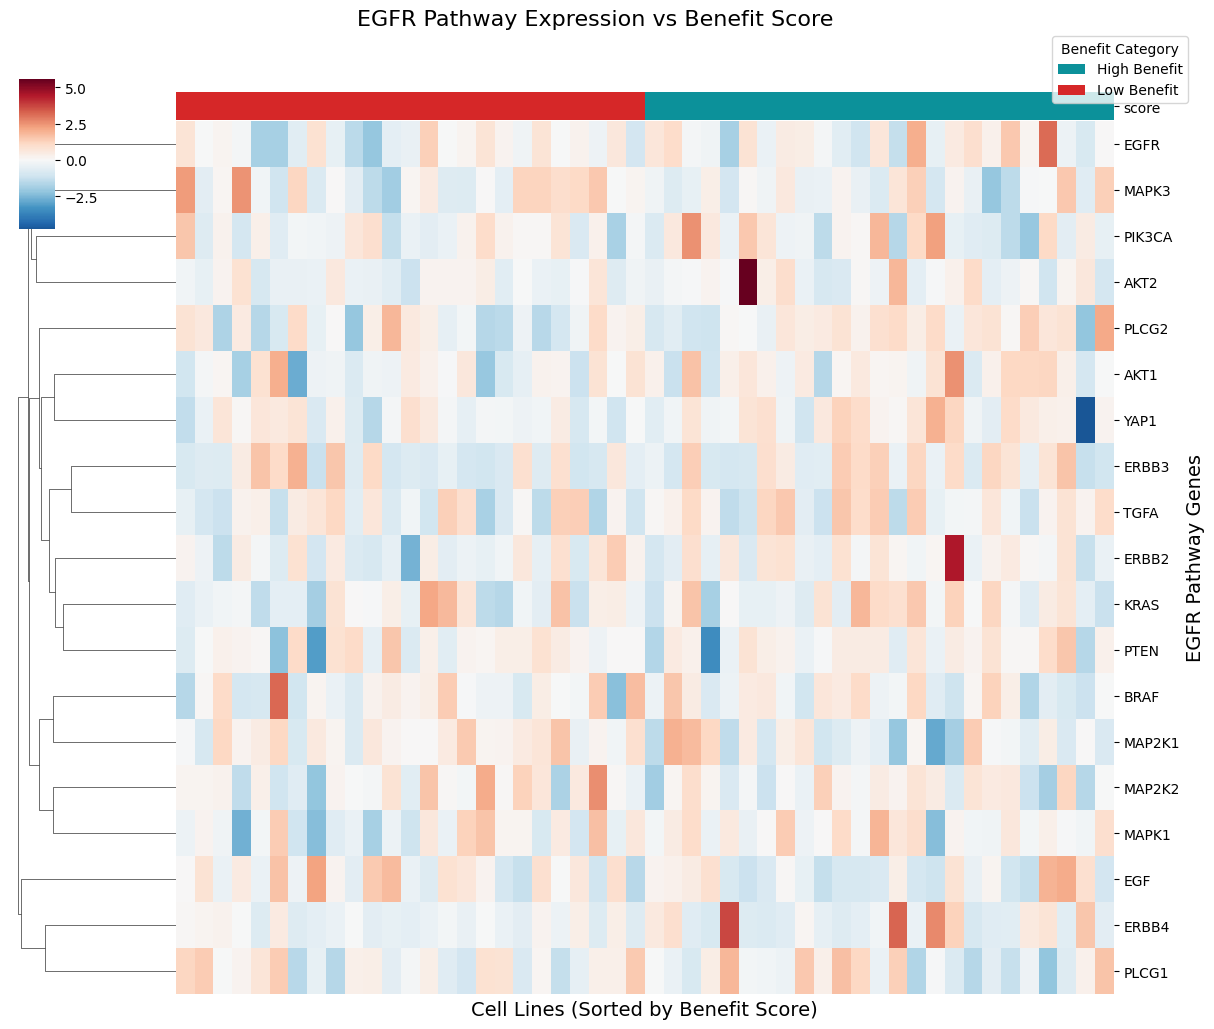

In [ ]:
# ==========================================
# 1. Configuration & Gene List
# ==========================================
FILE_PATH = '/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/Tahoe_analysis/Tahoe_voom_exp_final.csv'
WEIGHTS_PATH = '/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/git_repo/Data/EGFR_ERLOTINIB_geneImp_optuna.csv'

# Define the Target Genes (converting common names to HUGO symbols where necessary)
# Note: MEK -> MAP2K1/2, ERK -> MAPK1/3, YAP -> YAP1
TARGET_GENES = [
    # Receptors
    'EGFR', 'ERBB2', 'ERBB3', 'ERBB4',
    # Ligands
    'EGF', 'TGFA',
    # RAS/MAPK
    'KRAS', 'BRAF', 'MAP2K1', 'MAP2K2', 'MAPK1', 'MAPK3',
    # PI3K/AKT
    'PIK3CA', 'PTEN', 'AKT1', 'AKT2',
    # PLC
    'PLCG1', 'PLCG2',
    # YAP
    'YAP1' 
]

# ==========================================
# 2. Data Loading & Cleaning
# ==========================================
print("Loading Data...")
df = pd.read_csv(FILE_PATH)

# Handle Index
if 'Unnamed: 0' in df.columns:
    df.set_index('Unnamed: 0', inplace=True)
if 'clean_id' in df.columns:
    df.drop(columns=['clean_id'], inplace=True)

# Alias Mapping (Same as previous context)
alias_map = {
    'ENSG00000253102': 'LRRC59-AS1',
    'ENSG00000228925': 'MCFD2-AS1',
    'ENSG00000241073': 'MFSD14A-AS1',
    'ENSG00000227741': 'PEA15-AS1',
    'KIAA1522': 'NHSL3'
}
df = df.rename(columns=alias_map)

# Metadata Extraction
def parse_metadata(idx):
    # Regex to find Cell Line in DMSO samples
    # Pattern: DMSO_Plate_X_CVCL_XXXX
    dmso_match = re.search(r'DMSO_Plate_\d+_(CVCL_[A-Za-z0-9]+)', idx)
    if dmso_match:
        return {'sample_id': idx, 'type': 'DMSO', 'cell_line': dmso_match.group(1)}
    return {'sample_id': idx, 'type': 'Treatment', 'cell_line': None}

meta = pd.DataFrame([parse_metadata(x) for x in df.index]).set_index('sample_id')

# ==========================================
# 3. Compute Benefit Scores
# ==========================================
print("Computing Benefit Scores...")

# Load Weights
gene_weights = pd.read_csv(WEIGHTS_PATH, index_col=0)
weight_col = 'scaled_combined' if 'scaled_combined' in gene_weights.columns else gene_weights.columns[0]
weights = gene_weights[weight_col]

# align genes
common_genes = df.columns.intersection(weights.index)
weights = weights.loc[common_genes]

# Filter for DMSO samples only
dmso_samples = meta[meta['type'] == 'DMSO'].index
dmso_exp = df.loc[dmso_samples, common_genes]

# Calculate Score: Dot Product
raw_scores = dmso_exp.dot(weights)

# Create DataFrame mapping Cell Line -> Score
score_df = pd.DataFrame({'score': raw_scores})
score_df['cell_line'] = meta.loc[dmso_samples, 'cell_line']

# Average score per cell line (handling replicates)
cell_scores = score_df.groupby('cell_line')['score'].mean()

# Determine High/Low based on Median
median_score = cell_scores.median()
categories = cell_scores.apply(lambda x: 'High Benefit' if x > median_score else 'Low Benefit')

# ==========================================
# 4. Prepare Heatmap Data
# ==========================================
print("Preparing Heatmap Matrix...")

# 1. Get average expression per cell line for DMSO samples only
# (We average replicates to get one column per cell line)
dmso_exp_full = df.loc[dmso_samples]
dmso_exp_full['cell_line'] = meta.loc[dmso_samples, 'cell_line']
avg_exp_per_cell = dmso_exp_full.groupby('cell_line').mean()

# 2. Filter for Target Genes
available_genes = [g for g in TARGET_GENES if g in avg_exp_per_cell.columns]
missing_genes = set(TARGET_GENES) - set(available_genes)
if missing_genes:
    print(f"Warning: The following genes were not found in expression data: {missing_genes}")

heatmap_data = avg_exp_per_cell[available_genes].T # Genes as rows, Cells as columns

# 3. Sort Columns (Cell Lines) by Benefit Score
# This makes the heatmap transition smoothly from Low to High score
sorted_cell_lines = cell_scores.sort_values().index
heatmap_data = heatmap_data[sorted_cell_lines]

# 4. Z-Score Normalization (Row-wise / Per Gene)
# Subtract mean and divide by std dev for each gene to make them comparable
heatmap_data_z = heatmap_data.apply(lambda x: (x - x.mean()) / x.std(), axis=1)

# ==========================================
# 5. Plotting
# ==========================================
print("Generating Heatmap...")

# Create Column Colors based on Category
# Map 'High Benefit' to one color and 'Low Benefit' to another
cat_series = categories.loc[sorted_cell_lines]
lut = {'High Benefit': '#0c919a', 'Low Benefit': '#d62728'} # Teal vs Red
col_colors = cat_series.map(lut)

# Create Clustermap
# col_cluster=False keeps the sorting by Benefit Score (Low -> High)
# row_cluster=True clusters genes that behave similarly
g = sns.clustermap(
    heatmap_data_z,
    col_cluster=False, 
    row_cluster=True,
    col_colors=col_colors,
    cmap='RdBu_r',       # Red = High Exp, Blue = Low Exp
    center=0,            # Center colormap at Z-score 0
    figsize=(12, 10),
    dendrogram_ratio=(0.15, 0.05), # Adjust size of dendrograms
    cbar_pos=(0.02, 0.8, 0.03, 0.15), # Position of colorbar
    xticklabels=False    # Hide cell line names if too many
)

# Customizing the Plot
g.ax_heatmap.set_xlabel("Cell Lines (Sorted by Benefit Score)", fontsize=14)
g.ax_heatmap.set_ylabel("EGFR Pathway Genes", fontsize=14)

# Add Legend for the Column Annotations (High/Low)
from matplotlib.patches import Patch
handles = [Patch(facecolor=lut[name]) for name in lut]
plt.legend(handles, lut, title='Benefit Category',
           bbox_to_anchor=(1, 1), bbox_transform=plt.gcf().transFigure, loc='upper right')

g.fig.suptitle("EGFR Pathway Expression vs Benefit Score", fontsize=16, y=1.02)

# Save
#save_path = '/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/Multi_drug_model/EGFR_Erlotinib/EGFR_multidrug_model/Figures/EGFR_pathway_heatmap.pdf'
# plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

Loading Data...
Aggregating Replicates...
Computing Benefit Scores...
Performing Independent Block Clustering...
  > Processing block: DMSO
  > Processing block: Erlotinib 0.05 µM
  > Processing block: Erlotinib 0.5 µM
  > Processing block: Erlotinib 5.0 µM
Normalizing Data for Visualization...
Generating Heatmap...


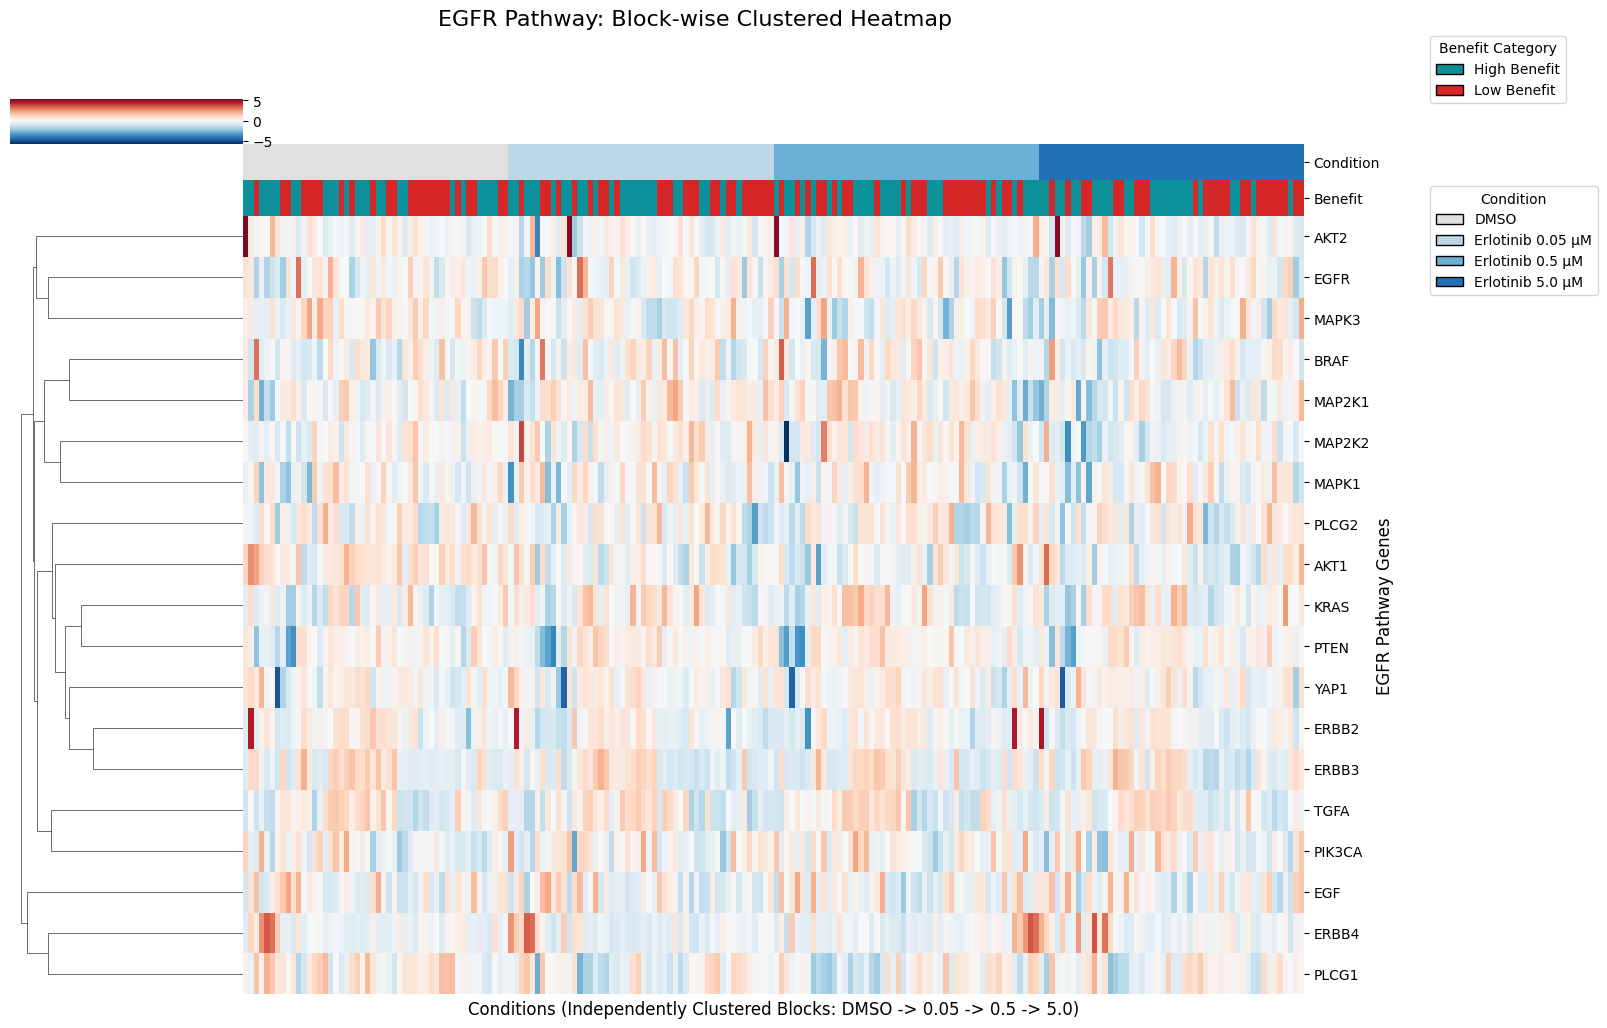

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
from matplotlib.patches import Patch
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist

# ==========================================
# 1. Configuration & Gene List
# ==========================================
FILE_PATH = '/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/Tahoe_analysis/Tahoe_voom_exp_final.csv'
WEIGHTS_PATH = '/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/git_repo/Data/EGFR_ERLOTINIB_geneImp_optuna.csv'

# Target Genes (EGFR Pathway)
TARGET_GENES = [
    'EGFR', 'ERBB2', 'ERBB3', 'ERBB4',
    'EGF', 'TGFA',
    'KRAS', 'BRAF', 'MAP2K1', 'MAP2K2', 'MAPK1', 'MAPK3',
    'PIK3CA', 'PTEN', 'AKT1', 'AKT2',
    'PLCG1', 'PLCG2',
    'YAP1' 
]

# ==========================================
# 2. Data Loading & Parsing
# ==========================================
print("Loading Data...")
df = pd.read_csv(FILE_PATH)

# Handle Index
if 'Unnamed: 0' in df.columns:
    df.set_index('Unnamed: 0', inplace=True)
if 'clean_id' in df.columns:
    df.drop(columns=['clean_id'], inplace=True)

# Alias Mapping
alias_map = {
    'ENSG00000253102': 'LRRC59-AS1',
    'ENSG00000228925': 'MCFD2-AS1',
    'ENSG00000241073': 'MFSD14A-AS1',
    'ENSG00000227741': 'PEA15-AS1',
    'KIAA1522': 'NHSL3'
}
df = df.rename(columns=alias_map)

# --- Metadata Extraction Function ---
def parse_metadata(idx):
    # Regex to capture Cell Line (CVCL_XXXX)
    cvcl_match = re.search(r'(CVCL_[A-Za-z0-9]+)', idx)
    cell_line = cvcl_match.group(1) if cvcl_match else None
    
    if 'DMSO' in idx:
        return {
            'sample_id': idx, 
            'cell_line': cell_line, 
            'condition': 'DMSO',
            'conc_sort': -1 # Ensure DMSO is first
        }
    elif 'Erlotinib' in idx:
        # Extract concentration (e.g., 0.05, 0.5, 5)
        # Pattern: Erlotinib_0.05_CVCL...
        parts = idx.split('_')
        try:
            conc = float(parts[1])
        except ValueError:
            conc = 0
            
        return {
            'sample_id': idx, 
            'cell_line': cell_line, 
            'condition': f'Erlotinib {conc} µM',
            'conc_sort': conc
        }
    return None

# Create Metadata DataFrame
meta_list = [parse_metadata(x) for x in df.index]
meta = pd.DataFrame([m for m in meta_list if m is not None]).set_index('sample_id')

# Merge metadata with expression data for aggregation
df_merged = df.join(meta[['cell_line', 'condition']])

# ==========================================
# 3. Aggregation (Averaging Replicates)
# ==========================================
print("Aggregating Replicates...")

# Group by Cell Line AND Condition, then calculate Mean
df_agg = df_merged.groupby(['cell_line', 'condition']).mean()

# ==========================================
# 4. Compute Benefit Scores (DMSO Only)
# ==========================================
print("Computing Benefit Scores...")

# Load Weights
gene_weights = pd.read_csv(WEIGHTS_PATH, index_col=0)
weight_col = 'scaled_combined' if 'scaled_combined' in gene_weights.columns else gene_weights.columns[0]
weights = gene_weights[weight_col]

# Align genes
common_genes = df_agg.columns.intersection(weights.index)
weights = weights.loc[common_genes]

# Extract DMSO specific data for scoring
dmso_data = df_agg.xs('DMSO', level='condition')[common_genes]

# Calculate Score
scores = dmso_data.dot(weights)

# Define Benefit Categories (High/Low)
median_score = scores.median()
benefit_map = scores.apply(lambda x: 'High Benefit' if x > median_score else 'Low Benefit')

# ==========================================
# 5. Block-wise Column Clustering
# ==========================================
print("Performing Independent Block Clustering...")

# 1. Setup the Matrix
available_genes = [g for g in TARGET_GENES if g in df_agg.columns]
# Transpose so: Rows = Genes, Cols = MultiIndex(Cell, Condition)
matrix_full = df_agg[available_genes].transpose() 

# 2. Define Strict Condition Order
# Ensure '5' matches '5.0' from metadata parsing logic
condition_order = ['DMSO', 'Erlotinib 0.05 µM', 'Erlotinib 0.5 µM', 'Erlotinib 5.0 µM']

ordered_columns = []
column_annotations = []

def cluster_columns_block(data_block):
    """
    data_block: Genes x Samples
    Performs hierarchical clustering on the samples based on gene expression profiles.
    Returns: The list of column names in clustered order.
    """
    if data_block.shape[1] < 2:
        return data_block.columns

    # 1. Row-wise Z-score for clustering calculation
    # We want to cluster samples that have similar RELATIVE gene patterns.
    # (High EGFR in Sample A matches High EGFR in Sample B)
    # axis=1 normalizes the genes (rows)
    block_norm = data_block.apply(lambda x: (x - x.mean()) / x.std(), axis=1)
    
    # 2. Distance (Euclidean distance between Columns)
    # pdist expects rows=observations. We transpose so rows=samples.
    dist = pdist(block_norm.T, metric='euclidean')
    
    # 3. Hierarchical Clustering
    Z = linkage(dist, method='average')
    
    # 4. Extract Order
    order_idx = leaves_list(Z)
    
    return data_block.columns[order_idx]

# 3. Loop through conditions and cluster independently
for cond in condition_order:
    print(f"  > Processing block: {cond}")
    
    # Select columns belonging to this condition
    # The columns of matrix_full are MultiIndex: (Cell_Line, Condition)
    cols = [c for c in matrix_full.columns if c[1] == cond]
    
    if not cols:
        print(f"    Warning: No data found for {cond}")
        continue

    # Extract block
    block = matrix_full[cols]
    
    # Cluster strictly within this block
    clustered_cols = cluster_columns_block(block)
    
    # Append to master list
    ordered_columns.extend(clustered_cols)
    
    # Create Annotation entries for this block
    for cell_line, _ in clustered_cols:
        ben = benefit_map.get(cell_line, 'Unknown')
        column_annotations.append({'Condition': cond, 'Benefit': ben})

# Reorder the Master Matrix
heatmap_data = matrix_full[ordered_columns]

# ==========================================
# 6. Normalization & Annotation for Plotting
# ==========================================
print("Normalizing Data for Visualization...")

# Z-score Row-wise (per gene) for the final heatmap colors
heatmap_z = heatmap_data.apply(lambda x: (x - x.mean()) / x.std(), axis=1)

# Prepare Annotation Dataframe
anno_df = pd.DataFrame(column_annotations, index=heatmap_data.columns)

# Define Colors
cond_lut = {
    'DMSO': '#e0e0e0',  # Light Grey
    'Erlotinib 0.05 µM': '#bdd7e7', # Light Blue
    'Erlotinib 0.5 µM': '#6baed6',  # Medium Blue
    'Erlotinib 5.0 µM': '#2171b5'   # Dark Blue
}
ben_lut = {'High Benefit': '#0c919a', 'Low Benefit': '#d62728'} # Teal / Red

row_colors_cond = anno_df['Condition'].map(cond_lut)
row_colors_ben = anno_df['Benefit'].map(ben_lut)
col_colors = pd.concat([row_colors_cond, row_colors_ben], axis=1)

# ==========================================
# 7. Plotting
# ==========================================
print("Generating Heatmap...")

g = sns.clustermap(
    heatmap_z,
    col_cluster=False,
    row_cluster=True,
    col_colors=col_colors,
    cmap='RdBu_r',
    center=0,
    figsize=(14, 10),
    xticklabels=False,
    yticklabels=True,
    dendrogram_ratio=(0.18, 0.05),
    colors_ratio=0.04,      # 👈 THIS increases space for color bars
    cbar_pos=(0.02, 0.8, 0.02, 0.15)
)


# Refine Labels
g.ax_heatmap.set_xlabel("Conditions (Independently Clustered Blocks: DMSO -> 0.05 -> 0.5 -> 5.0)", fontsize=12)
g.ax_heatmap.set_ylabel("EGFR Pathway Genes", fontsize=12)
g.fig.subplots_adjust(top=0.93)


# Legends
handles_ben = [Patch(facecolor=ben_lut[k], edgecolor='k', label=k) for k in ben_lut]
l1 = plt.legend(handles=handles_ben, title='Benefit Category', 
           bbox_to_anchor=(1.02, 1), bbox_transform=g.fig.transFigure, loc='upper left')

handles_cond = [Patch(facecolor=cond_lut[k], edgecolor='k', label=k) for k in condition_order if k in cond_lut]
plt.legend(handles=handles_cond, title='Condition', 
           bbox_to_anchor=(1.02, 0.85), bbox_transform=g.fig.transFigure, loc='upper left')

plt.gca().add_artist(l1)
g.fig.suptitle("EGFR Pathway: Block-wise Clustered Heatmap", fontsize=16, y=1.02)

# Save
# plt.savefig('EGFR_pathway_block_clustered.pdf', dpi=300, bbox_inches='tight')
plt.show()